#### <FONT size="10pt"> <center>Notebook 03 - Évaluation, Interprétabilité et Prédictions Finales</center></FONT>

## **Projet Rakuten - Classification multimodale de produits e-commerce**

Ce notebook couvre :
- **Section 1** : Configuration et chargement de tous les modèles sauvegardés
- **Section 2** : Prédictions finales sur X_test → fichier de soumission
- **Section 3** : Analyse d'erreurs approfondie sur le set de validation
- **Section 4** : Interprétation du meilleur modèle (TF-IDF + LinearSVC) et préparation de SHAP
- **Section 5** : Analyse des classes difficiles (codes 10 et 1281)
- **Section 6** : Comparaison croisée des modèles

> **Prérequis** : avoir exécuté le notebook 02 jusqu'à la fin. Tous les modèles et caches doivent être présents dans `models/`.

## 1 - Configuration et chargement des modèles

### 1.1 Imports

On charge l'ensemble des bibliothèques nécessaires au notebook : traitement des données (numpy, pandas), visualisation (matplotlib, seaborn), modèles sklearn (joblib, LabelEncoder, métriques), PyTorch pour les modèles deep learning, SHAP pour préparer un explainer, ainsi que les coefficients du modèle pour l'interprétation, et Sentence Transformers pour les embeddings texte.

In [1]:
import os
import sys
import warnings
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from PIL import Image

# Sklearn
import joblib
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (f1_score, classification_report, confusion_matrix)

# PyTorch
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader

# SHAP
import shap

# Sentence Transformers
from sentence_transformers import SentenceTransformer

warnings.filterwarnings("ignore")
np.random.seed(42)
torch.manual_seed(42)

print("Imports OK")

Imports OK


Tous les imports sont chargés sans erreur. SHAP est bien installé dans l'environnement `rakuten_env`.

### 1.2 Chemins du projet

On définit les chemins vers les répertoires de données, modèles, figures et soumissions. Ces chemins sont identiques à ceux du notebook 02 pour garantir la cohérence. On crée également le dossier `data/submissions/` s'il n'existe pas.

In [2]:
# Recherche robuste de la racine depuis le projet ou le dossier notebooks
START_DIR = Path.cwd().resolve()
PROJECT_ROOT = next(
    (candidate for candidate in [START_DIR, *START_DIR.parents]
     if (candidate / "data").is_dir() and (candidate / "notebooks").is_dir()),
    None
)
if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Impossible de localiser la racine contenant data et notebooks."
    )

DATA_PROC_DIR   = PROJECT_ROOT / "data" / "processed"
DATA_RAW_DIR    = PROJECT_ROOT / "data" / "raw"
IMAGE_TRAIN_DIR = PROJECT_ROOT / "data" / "raw" / "image_train"
IMAGE_TEST_DIR  = PROJECT_ROOT / "data" / "raw" / "image_test"
MODELS_DIR      = PROJECT_ROOT / "models"
FIGURES_DIR     = PROJECT_ROOT / "reports" / "figures"
ARTIFACTS_DIR   = PROJECT_ROOT / "models" / "artifacts"
SUBMISSIONS_DIR = PROJECT_ROOT / "data" / "submissions"
SUBMISSIONS_DIR.mkdir(parents=True, exist_ok=True)

print(f"PROJECT_ROOT    : {PROJECT_ROOT}")
print(f"MODELS_DIR      : {MODELS_DIR}")
print(f"SUBMISSIONS_DIR : {SUBMISSIONS_DIR}")

PROJECT_ROOT    : C:\Users\KhotyW\Documents\prive_khoty_wolie\RAKUTEN_PROJECT\project_rakuten_ml_dl
MODELS_DIR      : C:\Users\KhotyW\Documents\prive_khoty_wolie\RAKUTEN_PROJECT\project_rakuten_ml_dl\models
SUBMISSIONS_DIR : C:\Users\KhotyW\Documents\prive_khoty_wolie\RAKUTEN_PROJECT\project_rakuten_ml_dl\data\submissions


Les chemins pointent vers `C:\Users\KhotyW\...\project_rakuten_ml_dl`. Le dossier de soumission est créé automatiquement. Tous les chemins sont valides.

### 1.3 Device GPU

On détecte si un GPU est disponible. Les inférences des modèles PyTorch (MLP SBERT, ResNet50, MLP Fusion) seront exécutées sur GPU si disponible, ce qui réduit significativement le temps de calcul.

In [3]:
# Device GPU / CPU 
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device utilisé : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU : {torch.cuda.get_device_name(0)}")
    print(f"VRAM : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} Go")

Device utilisé : cuda
GPU : NVIDIA GeForce RTX 5070 Ti Laptop GPU
VRAM : 12.8 Go


Le GPU RTX 5070 Ti (12,8 Go VRAM) est détecté et actif. Les inférences PyTorch sont effectuées sur CUDA. Le pipeline TF-IDF + LinearSVC reste exécuté sur CPU et traite rapidement les 16 984 exemples de validation.


### 1.4 Chargement des données

On charge le dataset traité produit par le notebook 01 (`df_train_processed.csv`) ainsi que le fichier de test brut (`X_test_update.csv`). Pour le fichier de test, on reconstruit les colonnes `designation_clean`, `description_clean`, `text_combined` et `image_path` selon le même pipeline que le train.

In [4]:
# Chargement du dataset traité (produit par notebook 01)
processed_file = DATA_PROC_DIR / "df_train_processed.csv"
test_file = DATA_RAW_DIR / "X_test_update.csv"
if not processed_file.is_file():
    raise FileNotFoundError(f"Fichier processed introuvable : {processed_file}")
if not test_file.is_file():
    raise FileNotFoundError(f"Fichier test introuvable : {test_file}")

df = pd.read_csv(processed_file, low_memory=False)
required_columns = {
    "designation_clean", "description_clean", "text_combined",
    "image_path", "productid", "imageid", "prdtypecode"
}
missing_columns = sorted(required_columns.difference(df.columns))
if missing_columns:
    raise ValueError(f"Colonnes obligatoires absentes : {missing_columns}")
df["text_combined"] = df["text_combined"].fillna(df["designation_clean"]).fillna("").astype(str)

# Préparation du test avec le même pipeline textuel que le notebook 01
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem.snowball import FrenchStemmer

nltk.download("stopwords", quiet=True)
FRENCH_STOPWORDS = set(stopwords.words("french"))
STEMMER = FrenchStemmer()

def clean_text(text: str) -> str:
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-zA-ZÀ-ÿ0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    tokens = text.split()
    tokens = [t for t in tokens if t not in FRENCH_STOPWORDS and len(t) > 1]
    tokens = [STEMMER.stem(t) for t in tokens]
    return " ".join(tokens)

common_words_to_remove = [
    "the", "39", "01", "of", "cm", "and", "oui", "gi", "tai", "taill",
    "in", "oh", "10", "not", "plus", "sous", "vf", "11", "to", "34",
    "03", "fr", "12", "for", "09", "or", "04"
]
words_to_remove_set = set(common_words_to_remove)

def remove_custom_stopwords(text: str) -> str:
    if not isinstance(text, str):
        return text
    return " ".join(word for word in text.split() if word not in words_to_remove_set)

df_test = pd.read_csv(test_file, low_memory=False)
df_test.rename(columns={df_test.columns[0]: "idx"}, inplace=True)
df_test["designation_clean"] = df_test["designation"].fillna("").astype(str).apply(clean_text)
df_test["description_clean"] = df_test["description"].fillna("").astype(str).apply(clean_text)
df_test["text_concat"] = (
    df_test["designation_clean"] + " " + df_test["description_clean"]
).str.strip().apply(remove_custom_stopwords)
df_test["text_combined"] = df_test["text_concat"].fillna("").astype(str)
empty_text_mask = df_test["text_combined"].str.strip().eq("")
df_test.loc[empty_text_mask, "text_combined"] = (
    df_test.loc[empty_text_mask, "designation_clean"].fillna("").astype(str)
)
df_test["image_path"] = df_test.apply(
    lambda r: str(IMAGE_TEST_DIR / f"image_{r['imageid']}_product_{r['productid']}.jpg"),
    axis=1
)

print(f"Dataset train : {df.shape}")
print(f"Dataset test  : {df_test.shape}")
print(f"Classes       : {df['prdtypecode'].nunique()}")

Dataset train : (84916, 29)
Dataset test  : (13812, 10)
Classes       : 27


Le dataset train contient 84 916 lignes et 29 colonnes. Le dataset test contient 13 812 produits et 10 colonnes après reconstruction des variables nettoyées. Les 27 classes sont bien présentes dans le train.


### 1.5 Reconstitution du split train/val

On reproduit exactement le split 80/20 stratifié du notebook 02 (random_state=42). Cette étape est critique : utiliser un split différent invaliderait toutes les comparaisons de métriques entre les notebooks.

In [5]:
# Split train/val identique au notebook 02 
from sklearn.model_selection import train_test_split

X = df[["text_combined", "image_path", "productid", "imageid", "designation", "description"]]
y = df["prdtypecode"]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train : {len(X_train)} | Val : {len(X_val)}")
print(f"Ecart max de distribution : {max(abs(y_train.value_counts(normalize=True) - y_val.value_counts(normalize=True))):.4f}")

Train : 67932 | Val : 16984
Ecart max de distribution : 0.0000


Le split est identique : 67 932 exemples en train, 16 984 en validation. L'écart maximal de distribution entre train et val est de 0,0000, ce qui confirme que le split stratifié est parfaitement reproductible.

### 1.6 Définition des classes partagées

On redéfinit les trois classes PyTorch utilisées dans le notebook 02 : `EmbeddingDataset` (dataset générique pour embeddings pré-calculés), `MLPClassifier` (réseau MLP configurable), et `build_resnet50` (ResNet50 pré-entraîné avec tête FC personnalisée). Ces définitions sont nécessaires pour charger les poids sauvegardés.

In [6]:
# Définitions des classes partagées (identiques au notebook 02)

class EmbeddingDataset(Dataset):
    """Dataset PyTorch pour les embeddings pré-calculés."""
    def __init__(self, embeddings, labels):
        self.X = torch.tensor(embeddings, dtype=torch.float32)
        self.y = torch.tensor(labels,     dtype=torch.long)
    def __len__(self):            return len(self.y)
    def __getitem__(self, idx):   return self.X[idx], self.y[idx]


class MLPClassifier(nn.Module):
    """MLP générique : Linear + BatchNorm + ReLU + Dropout, configurable."""
    def __init__(self, input_dim, num_classes, hidden_dims=(512, 256), dropout=0.3):
        super().__init__()
        layers, prev_dim = [], input_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev_dim, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            prev_dim = h
        layers.append(nn.Linear(prev_dim, num_classes))
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)


def build_resnet50(num_classes, freeze_backbone=False):
    """ResNet50 pré-entraîné ImageNet avec tête FC personnalisée."""
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False
    in_features = model.fc.in_features  # 2048
    model.fc = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(in_features, 512),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(512, num_classes))
    
    return model


print("Classes définies : EmbeddingDataset, MLPClassifier, build_resnet50")

Classes définies : EmbeddingDataset, MLPClassifier, build_resnet50


Les trois classes sont définies. Leur architecture est identique à celle du notebook 02, ce qui est indispensable pour que `load_state_dict` fonctionne correctement.

### 1.7 Chargement du LabelEncoder et des caches

On reconstruit le LabelEncoder à l'identique (ajustement sur l'ensemble du dataset), puis on charge les caches pré-calculés : embeddings SBERT (shape 84 916 × 384) et features ResNet50 (shape 84 916 × 2048). On réindexe ensuite ces matrices pour extraire les sous-ensembles train et val correspondant au split. Enfin, on concatène les deux types de features pour former les vecteurs multimodaux (2 432 dimensions).

In [7]:
# Chargement du LabelEncoder et des caches 

# LabelEncoder : reconstruit sur l'ensemble du dataset (même ordre que notebook 02)
labels_all = df["prdtypecode"].values
le = LabelEncoder()
le.fit(labels_all)
NUM_CLASSES = len(le.classes_)

y_train_enc = le.transform(y_train)
y_val_enc   = le.transform(y_val)

print(f"Nombre de classes : {NUM_CLASSES}")
print(f"Classes (codes)   : {le.classes_}")

# Cache embeddings SBERT 
SBERT_CACHE = ARTIFACTS_DIR / "sbert_embeddings_train.npy"
assert SBERT_CACHE.exists(), f"Cache SBERT introuvable : {SBERT_CACHE}"
emb_all = np.load(SBERT_CACHE)
print(f"Embeddings SBERT chargés : {emb_all.shape}")

# Mapping index DataFrame → position dans la matrice d'embeddings
df_idx_map = {idx: pos for pos, idx in enumerate(df.index)}
train_idx  = [df_idx_map[i] for i in X_train.index]
val_idx    = [df_idx_map[i] for i in X_val.index]

emb_train  = emb_all[train_idx]
emb_val    = emb_all[val_idx]

# Cache features ResNet50 
FEATURES_CACHE = ARTIFACTS_DIR / "resnet50_features_train.npy"
assert FEATURES_CACHE.exists(), f"Cache ResNet50 introuvable : {FEATURES_CACHE}"
img_features_all = np.load(FEATURES_CACHE)
print(f"Features ResNet50 chargées : {img_features_all.shape}")

img_train = img_features_all[train_idx]
img_val   = img_features_all[val_idx]

# Features multimodales (concaténation)
mm_train = np.concatenate([emb_train, img_train], axis=1)
mm_val   = np.concatenate([emb_val,   img_val],   axis=1)
print(f"Features multimodales : {mm_train.shape[1]} dimensions (384 SBERT + 2048 ResNet50)")

Nombre de classes : 27
Classes (codes)   : [  10   40   50   60 1140 1160 1180 1280 1281 1300 1301 1302 1320 1560
 1920 1940 2060 2220 2280 2403 2462 2522 2582 2583 2585 2705 2905]
Embeddings SBERT chargés : (84916, 384)
Features ResNet50 chargées : (84916, 2048)
Features multimodales : 2432 dimensions (384 SBERT + 2048 ResNet50)


27 classes sont encodées. Les caches SBERT et ResNet50 sont chargés depuis le disque. La concaténation produit des vecteurs de 2 432 dimensions (384 SBERT + 2 048 ResNet50), ce qui correspond bien à l'architecture du MLP de fusion.

### 1.8 Chargement de tous les modèles

On charge en mémoire les quatre modèles entraînés dans le notebook 02 :
- **TF-IDF + LinearSVC** : pipeline sklearn sérialisé via joblib
- **MLP SBERT** : réseau PyTorch (384 vers 512 vers 256 vers 27), meilleur checkpoint sauvegardé
- **ResNet50** : modèle fine-tuné en phase 2, meilleur checkpoint sauvegardé
- **MLP Fusion** : réseau PyTorch (2 432 vers 1 024 vers 512 vers 256 vers 27), meilleur checkpoint sauvegardé

Les modèles PyTorch sont placés en mode `.eval()` avant l'inférence.


In [8]:
# Chargement du modèle baseline TF-IDF + LinearSVC 
pipeline_svc = joblib.load(MODELS_DIR / "baselines" / "tfidf_linearsvc.pkl")
print("TF-IDF + LinearSVC chargé")

# Chargement du MLP SBERT 
mlp_sbert = MLPClassifier(input_dim=384, num_classes=NUM_CLASSES,
                          hidden_dims=(512, 256), dropout=0.3).to(DEVICE)
mlp_sbert.load_state_dict(
    torch.load(MODELS_DIR / "text" / "mlp_sbert_best.pt", map_location=DEVICE))
mlp_sbert.eval()
print("MLP SBERT chargé")

# Chargement du ResNet50 
resnet_model = build_resnet50(num_classes=NUM_CLASSES, freeze_backbone=False).to(DEVICE)
resnet_model.load_state_dict(
    torch.load(MODELS_DIR / "image" / "resnet50_phase2_best.pt", map_location=DEVICE))
resnet_model.eval()
print("ResNet50 Phase 2 chargé")

# Chargement du MLP de fusion 
MM_DIM = mm_train.shape[1]  # 2432
mlp_fusion = MLPClassifier(input_dim=MM_DIM, num_classes=NUM_CLASSES,
                           hidden_dims=(1024, 512, 256), dropout=0.4).to(DEVICE)
mlp_fusion.load_state_dict(
    torch.load(MODELS_DIR / "text" / "mlp_fusion_best.pt", map_location=DEVICE))
mlp_fusion.eval()
print("MLP Fusion chargé")

print("\nTous les modèles sont chargés et prêts.")

TF-IDF + LinearSVC chargé
MLP SBERT chargé
ResNet50 Phase 2 chargé
MLP Fusion chargé

Tous les modèles sont chargés et prêts.


Les quatre modèles sont chargés sans erreur et prêts pour l'inférence. Le mode `.eval()` désactive le dropout et utilise les statistiques mémorisées par les couches BatchNorm.


## 2 - Prédictions finales sur X_test

Le meilleur modèle, TF-IDF + LinearSVC avec un F1 pondéré de 0,8316, est utilisé pour générer les prédictions sur les 13 812 produits du jeu de test. Le fichier produit respecte le format attendu par le challenge Rakuten.


### 2.1 Génération des prédictions sur X_test

On applique le meilleur modèle, TF-IDF + LinearSVC avec un F1 pondéré de 0,8316, aux 13 812 produits du jeu de test. Le texte combiné nettoyé est vectorisé à la volée par le `TfidfVectorizer` intégré au pipeline, puis classifié.


In [9]:
# Prédictions TF-IDF + LinearSVC sur X_test 
t0 = time.time()
y_pred_test = pipeline_svc.predict(df_test["text_combined"])
print(f"Prédictions générées en {time.time()-t0:.1f}s")
print(f"Nombre de prédictions : {len(y_pred_test)}")
print(f"Classes prédites (distribution) :")
pred_counts = pd.Series(y_pred_test).value_counts().sort_index()
print(pred_counts)

Prédictions générées en 0.9s
Nombre de prédictions : 13812
Classes prédites (distribution) :
10       508
40       344
50       266
60       129
1140     458
1160     676
1180      94
1280     735
1281     300
1300     911
1301     143
1302     400
1320     513
1560     793
1920     671
1940     128
2060     805
2220     154
2280     878
2403     794
2462     225
2522     882
2582     335
2583    1679
2585     424
2705     442
2905     125
Name: count, dtype: int64


Les 13 812 prédictions sont générées en 0,9 seconde. Les 27 classes sont représentées. La classe 2583 est la plus prédite avec 1 679 produits, une valeur proche de celle attendue d'après sa proportion dans le train. Les classes 1180 et 2905 restent parmi les moins prédites, avec respectivement 94 et 125 produits.


### 2.2 Export du fichier de soumission

On produit le fichier CSV au format exact attendu par le challenge Rakuten : index entier en première colonne, `prdtypecode` en deuxième. Ce fichier peut être soumis directement sur challengedata.ens.fr.

In [10]:
# Export du fichier de soumission 
# Format attendu par le challenge : index entier + prdtypecode
submission = pd.DataFrame({
    "": df_test["idx"],
    "prdtypecode": y_pred_test})

submission.set_index("", inplace=True)

submission_path = SUBMISSIONS_DIR / "submission_tfidf_svc.csv"
submission.to_csv(submission_path)
print(f"Fichier de soumission sauvegardé : {submission_path}")
print(f"Format : {submission.shape}")
print("\nAperçu (5 premières lignes) :")
print(submission.head())

Fichier de soumission sauvegardé : C:\Users\KhotyW\Documents\prive_khoty_wolie\RAKUTEN_PROJECT\project_rakuten_ml_dl\data\submissions\submission_tfidf_svc.csv
Format : (13812, 1)

Aperçu (5 premières lignes) :
       prdtypecode
                  
84916         1280
84917         1160
84918         2583
84919         2583
84920         2522


Le fichier `submission_tfidf_svc.csv` est sauvegardé. Il contient 13 812 lignes au format attendu. On vérifie en tête que les index correspondent bien aux identifiants du fichier X_test.

### 2.3 Comparaison des distributions train vs test

On visualise côte à côte la distribution des classes dans le train (labels réels) et dans le test (prédictions). Si le modèle est bien calibré, les deux distributions doivent être proportionnelles, reflétant un déséquilibre similaire des classes.

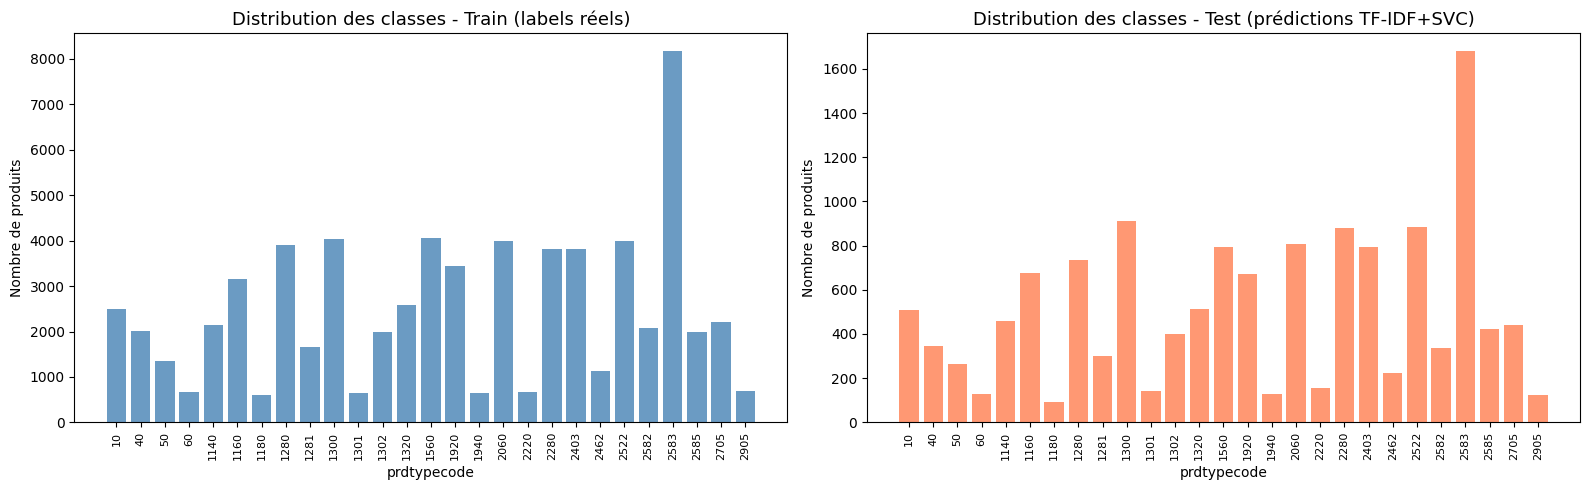

Figure 14 sauvegardée.


In [11]:
# Visualisation de la distribution des prédictions test vs train 
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Distribution train (labels réels)
train_dist = y_train.value_counts().sort_index()
axes[0].bar(range(len(train_dist)), train_dist.values, color="steelblue", alpha=0.8)
axes[0].set_xticks(range(len(train_dist)))
axes[0].set_xticklabels(train_dist.index, rotation=90, fontsize=8)
axes[0].set_title("Distribution des classes - Train (labels réels)", fontsize=13)
axes[0].set_xlabel("prdtypecode")
axes[0].set_ylabel("Nombre de produits")

# Distribution test (prédictions)
test_dist = pd.Series(y_pred_test).value_counts().sort_index()
axes[1].bar(range(len(test_dist)), test_dist.values, color="coral", alpha=0.8)
axes[1].set_xticks(range(len(test_dist)))
axes[1].set_xticklabels(test_dist.index, rotation=90, fontsize=8)
axes[1].set_title("Distribution des classes - Test (prédictions TF-IDF+SVC)", fontsize=13)
axes[1].set_xlabel("prdtypecode")
axes[1].set_ylabel("Nombre de produits")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "14_distribution_predictions_test.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 14 sauvegardée.")

Les distributions restent globalement cohérentes et la classe 2583 domine dans les deux ensembles. Par rapport aux proportions du train, la classe 1280 est légèrement sous-représentée dans le test, avec 735 prédictions contre environ 792 attendues. La classe 1300 est davantage représentée, avec 911 prédictions contre environ 821 attendues. Ces écarts décrivent la distribution prédite, sans fournir à eux seuls une mesure de calibration.


## 3 - Analyse d'erreurs approfondie sur la validation

Analyse détaillée des erreurs du meilleur modèle (TF-IDF + LinearSVC) sur le set de validation.

### 3.1 Métriques globales sur la validation

On régénère les prédictions du TF-IDF + LinearSVC sur le set de validation et on calcule le weighted F1-score ainsi que le nombre total d'erreurs. On construit également un DataFrame `df_val_results` qui aligne prédictions, labels réels et indicateur de correction, pour faciliter l'analyse d'erreurs.

In [12]:
# Régénération des prédictions de validation 
y_pred_svc_val = pipeline_svc.predict(X_val["text_combined"])

f1_val = f1_score(y_val, y_pred_svc_val, average="weighted")
print(f"Weighted F1 (validation) : {f1_val:.4f}")

# DataFrame d'erreurs
df_val_results = X_val.copy()
df_val_results["y_true"] = y_val.values
df_val_results["y_pred"] = y_pred_svc_val
df_val_results["correct"] = df_val_results["y_true"] == df_val_results["y_pred"]

n_errors = (~df_val_results["correct"]).sum()
print(f"Erreurs totales : {n_errors} / {len(df_val_results)} ({n_errors/len(df_val_results)*100:.1f}%)")

Weighted F1 (validation) : 0.8316
Erreurs totales : 2833 / 16984 (16.7%)


Le modèle atteint un F1 pondéré de **0,8316** sur la validation, soit environ **+0,0203** par rapport au benchmark Rakuten à 0,8113. Sur 16 984 exemples, **2 833 sont mal classés (16,7 %)**.


### 3.2 F1-score par classe

On calcule le rapport de classification complet (précision, rappel, F1, support) pour chacune des 27 classes. On filtre les classes dont le F1 est inférieur à 0,70 pour identifier les cas problématiques qui méritent une attention particulière.

In [13]:
# F1-score par classe avec support 
report_dict = classification_report(
    y_val, y_pred_svc_val, output_dict=True, zero_division=0)

classes = sorted(df["prdtypecode"].unique())

df_report = pd.DataFrame([
    {
        "classe": cls,
        "f1": report_dict[str(cls)]["f1-score"],
        "precision": report_dict[str(cls)]["precision"],
        "recall": report_dict[str(cls)]["recall"],
        "support": report_dict[str(cls)]["support"]
    }
    for cls in classes
]).sort_values("f1")

print("Classes avec F1 < 0.70 :")
print(df_report[df_report["f1"] < 0.70].to_string(index=False))

Classes avec F1 < 0.70 :
 classe       f1  precision   recall  support
     10 0.525799   0.536789 0.515249    623.0
   1281 0.598179   0.647887 0.555556    414.0
   1180 0.682171   0.838095 0.575163    153.0
   1280 0.691529   0.718715 0.666324    974.0


Quatre classes passent sous le seuil F1 = 0,70 :
- **Classe 10** : F1 = 0,526, précision = 0,537, rappel = 0,515 sur 623 exemples.
- **Classe 1281** : F1 = 0,598, précision = 0,648, rappel = 0,556 sur 414 exemples.
- **Classe 1180** : F1 = 0,682, précision = 0,838, rappel = 0,575 sur 153 exemples. La précision élevée contraste avec un rappel plus faible.
- **Classe 1280** : F1 = 0,692, précision = 0,719, rappel = 0,666 sur 974 exemples.

Les 23 autres classes atteignent au moins 0,70. Les classes 10 et 1281 restent les deux plus difficiles.


### 3.3 Analyse des paires de confusion

On recense toutes les erreurs et on les agrège par paire (classe réelle, classe prédite) pour identifier les confusions systématiques du modèle. Les top 20 paires révèlent les frontières de décision les plus floues.

In [14]:
# Top 20 des paires de classes confondues 
errors_only = df_val_results[~df_val_results["correct"]]

confusion_pairs = (
    errors_only.groupby(["y_true", "y_pred"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
    .head(20))

confusion_pairs.columns = ["Classe réelle", "Classe prédite", "Nb erreurs"]
print("Top 20 des confusions :")
print(confusion_pairs.to_string(index=False))

Top 20 des confusions :
 Classe réelle  Classe prédite  Nb erreurs
          2403            2280         131
          1280            1300         115
            10            2280          90
          1281            1280          88
            10            2403          83
          2705              10          73
          2280            2403          72
          2403              10          67
          1280            1281          59
            10            2705          57
          2060            1560          47
          2280              10          46
          2582            1560          42
          1560            2060          42
          1280            1140          42
          2705            2280          38
          2060            1920          32
            40              10          31
          2705            2403          30
          2280            2705          28


Les confusions les plus fréquentes sont :
- **2403 vers 2280** : 131 cas, contre 72 cas dans le sens inverse.
- **1280 vers 1300** : 115 cas.
- **10 vers 2280** : 90 cas.
- **1281 vers 1280** : 88 cas.
- **10 vers 2403** : 83 cas.
- **2705 vers 10** : 73 cas.

Les catégories éditoriales 10, 2280, 2403 et 2705 se confondent fréquemment. Les classes 1280 et 1281 présentent également une confusion notable entre jouets et jeux de société. Ces résultats sont compatibles avec des frontières sémantiques proches, sans permettre d'attribuer toutes les erreurs à la seule ambiguïté des produits.


### 3.4 Exemples qualitatifs d'erreurs

On affiche 6 exemples de produits mal classés pour comprendre qualitativement pourquoi le modèle échoue. L'analyse textuelle de chaque exemple permet d'identifier si l'erreur est compréhensible ou si elle révèle un angle mort du modèle.

In [15]:
# Exemples de produits mal classés 
# Affichage de 6 exemples d'erreurs instructives
print("=== Exemples de produits mal classés (TF-IDF + LinearSVC) ===\n")

sample_errors = errors_only.sample(n=min(6, len(errors_only)), random_state=42)

for _, row in sample_errors.iterrows():
    print(f"Classe réelle  : {row['y_true']}")
    print(f"Classe prédite : {row['y_pred']}")
    print(f"Désignation    : {row['designation'][:120]}")
    if pd.notna(row.get('description')) and str(row.get('description','')):
        print(f"Description    : {str(row['description'])[:120]}")
    print("-" * 80)

=== Exemples de produits mal classés (TF-IDF + LinearSVC) ===

Classe réelle  : 2060
Classe prédite : 1920
Désignation    : Feuilles Sheer Rideau Tulle Fenêtre Traitement Drapé Valance 1 Voile Tissu De Panneau Lujuik
Description    : Laisse Sheer rideau traitement Tulle fenêtre Valance 1 Drapé Voile panneau en tissu point de vente du produit: filtre la
--------------------------------------------------------------------------------
Classe réelle  : 2403
Classe prédite : 2280
Désignation    : Cuisine Chinoise Indienne Et Exotique
--------------------------------------------------------------------------------
Classe réelle  : 1920
Classe prédite : 1560
Désignation    : Décoration Rectangulaire Nappe Polyester Table Tissu Taille Pleine Tablecloth 205
Description    : Décoration rectangulaire Nappe Polyester Table Tissu Taille pleine ProductSellingpoints: 100% qualité de marque nouvelle
--------------------------------------------------------------------------------
Classe réelle  : 2280


Les six exemples affichés illustrent plusieurs formes d'ambiguïté :
1. Des produits de décoration proches, comme un rideau de classe 2060 prédit 1920 et une nappe de classe 1920 prédite 1560.
2. Des catégories éditoriales voisines, avec *Cuisine Chinoise Indienne Et Exotique* classé 2280 au lieu de 2403 et un numéro de *Midi Olympique* classé 10 au lieu de 2280.
3. Des désignations techniques ou courtes, comme un testeur de servo de classe 50 prédit 1300 et une pile pour balance de classe 2585 prédite 1280.

Ces cas montrent les limites du signal textuel lorsque le vocabulaire est partagé ou peu spécifique. Ils motivent l'étude du signal visuel, sans garantir que la fusion corrige chaque erreur.


### 3.5 Matrice de confusion des classes faibles

On sélectionne les 10 classes ayant les F1 les plus faibles, puis les observations dont la classe réelle ou prédite appartient à cet ensemble. La matrice affiche donc aussi les autres classes impliquées dans ces erreurs. L'interprétation du rappel doit se concentrer sur les lignes correspondant aux 10 classes sélectionnées.


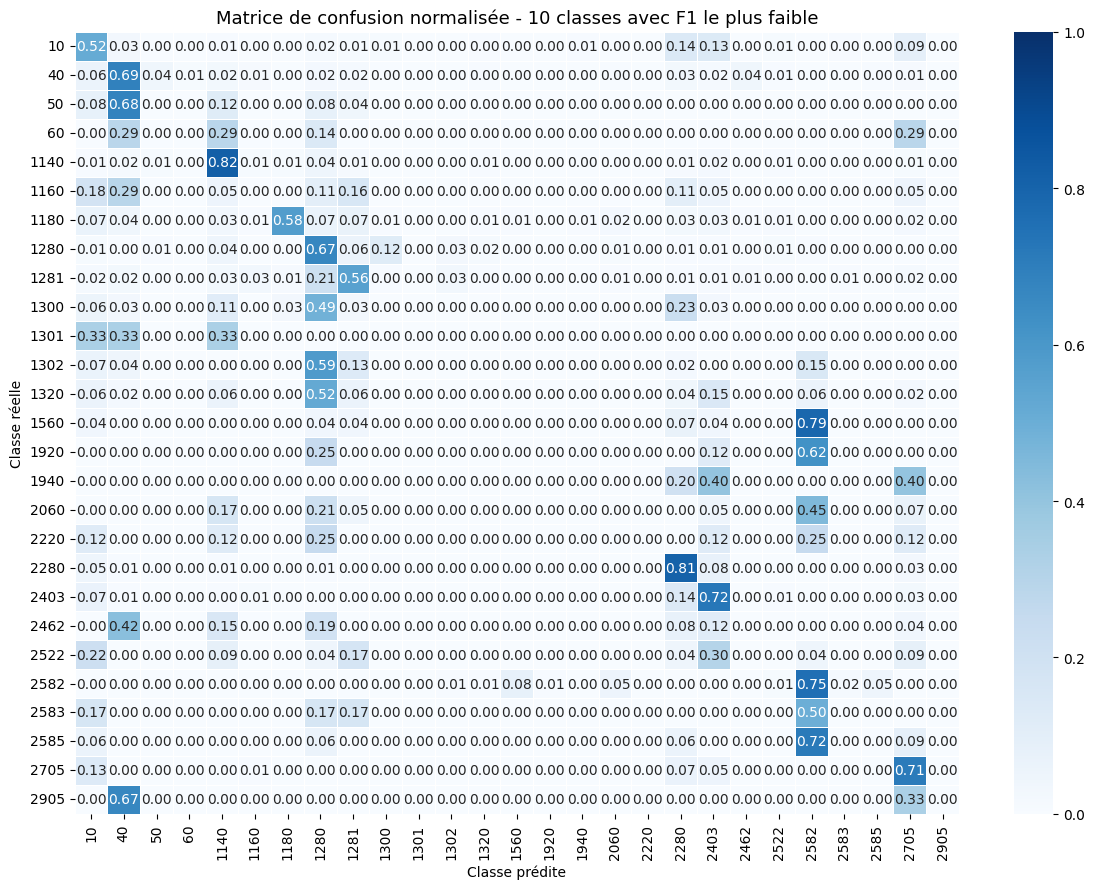

Figure 15 sauvegardée.


In [16]:
# Visualisation des erreurs par classe (heatmap) 
# Matrice de confusion normalisée (recall) pour les 10 classes les plus confondues
classes_worst = df_report.head(10)["classe"].tolist()

mask = df_val_results["y_true"].isin(classes_worst) | df_val_results["y_pred"].isin(classes_worst)
df_sub = df_val_results[mask]

cm_sub = confusion_matrix(
    df_sub["y_true"], df_sub["y_pred"],
    labels=sorted(df_sub["y_true"].unique()))

# Normalisation par ligne (recall)
cm_norm = cm_sub.astype(float) / (cm_sub.sum(axis=1, keepdims=True) + 1e-9)

fig, ax = plt.subplots(figsize=(12, 9))
labels_used = sorted(df_sub["y_true"].unique())
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=labels_used, yticklabels=labels_used,
            linewidths=0.5, ax=ax, vmin=0, vmax=1)
ax.set_title("Matrice de confusion normalisée - 10 classes avec F1 le plus faible", fontsize=13)
ax.set_xlabel("Classe prédite")
ax.set_ylabel("Classe réelle")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "15_confusion_classes_faibles.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 15 sauvegardée.")

Pour les 10 classes ciblées, la diagonale confirme les difficultés déjà mesurées :
- **Classe 10** : rappel proche de 0,52, avec des confusions vers 2280, 2403 et 2705.
- **Classe 1281** : rappel de 0,56, avec 0,21 des produits dirigés vers 1280.
- **Classe 1180** : rappel de 0,58.
- **Classe 1280** : rappel de 0,67, notamment avec une confusion vers 1300.
- **Classes 2280 et 2403** : rappels proches de 0,81 et 0,72, avec des échanges entre ces catégories éditoriales.

Les lignes supplémentaires proviennent du filtre sur les classes prédites. Elles ne représentent pas le rappel complet de ces autres classes.


## 4 - Interprétation du modèle TF-IDF + LinearSVC

SHAP (SHapley Additive exPlanations) fournit un cadre général pour expliquer les prédictions. Un objet `shap.LinearExplainer` est initialisé dans cette section, mais les visualisations suivantes n'appellent pas cet explainer. Elles analysent directement les coefficients du LinearSVC et, pour un exemple, les contributions additives au score de décision calculées par `coefficient × valeur TF-IDF`.

### 4.1 Préparation de l'explainer SHAP

#### Difficultés rencontrées et choix techniques

L'intégration de SHAP dans ce notebook a nécessité deux ajustements importants.

**1. Installation de SHAP.**
La bibliothèque SHAP n'était pas installée dans l'environnement `rakuten_env`. Une tentative d'exécution directe provoquait un `ModuleNotFoundError`. L'installation a été réalisée via :
```bash
conda activate rakuten_env
pip install shap
```
Un redémarrage du kernel Jupyter a ensuite été nécessaire pour que Python prenne en compte le nouveau package.

**2. Erreur mémoire sur le calcul batch des valeurs SHAP.**
L'appel initial `explainer.shap_values(X_val_tfidf)` sur 500 exemples a déclenché un `MemoryError` :
```
Unable to allocate 763 MiB for an array with shape (500, 200000) and dtype float64
```
La cause est la densification de la matrice TF-IDF creuse (sparse) lors du calcul SHAP. SHAP tente de matérialiser en RAM un tableau dense de 500 × 200 000 valeurs float64, soit environ 763 Mo. Sur la machine utilisée (32 Go RAM, mais déjà sollicitée par les autres objets en mémoire), cette allocation échoue.

**Solution retenue.** Le calcul SHAP sur un batch complet est évité. Pour interpréter le LinearSVC sans densifier la matrice, le notebook exploite directement :
- les coefficients du modèle, comme indicateurs globaux signés de l'association entre les tokens et chaque classe ;
- le produit `coefficient × valeur TF-IDF`, comme contribution additive locale de chaque token au score de décision d'une classe, hors intercept.

Ce produit décrit fidèlement la décomposition du score du modèle linéaire, mais il ne constitue pas une valeur SHAP calculée par `shap.LinearExplainer`. L'explainer est seulement initialisé sur 50 exemples de référence. Il n'est pas appelé par les analyses qui suivent. Cette approche est instantanée et évite la densification qui avait provoqué l'erreur mémoire.

In [17]:
# Préparation du vectoriseur et de l'explainer SHAP
# Extraction des composants du pipeline sklearn
print("Steps du pipeline :", pipeline_svc.steps)

vectorizer = pipeline_svc.steps[0][1]   # TfidfVectorizer
classifier = pipeline_svc.steps[-1][1]  # LinearSVC

# Les coefficients servent ici d'indicateurs globaux signés du modèle linéaire.
# On initialise l'explainer, mais on ne calcule pas de valeurs SHAP sur le batch.
# Les analyses suivantes utilisent directement les coefficients et coefficient × TF-IDF.
N_SHAP_SAMPLES = 50   # réduit à 50 pour l'explainer de référence uniquement
X_val_sample   = X_val["text_combined"].sample(n=N_SHAP_SAMPLES, random_state=42)
X_val_tfidf    = vectorizer.transform(X_val_sample)

# Explainer léger : masker sparse, pas de densification
masker   = shap.maskers.Independent(X_val_tfidf, max_samples=50)
explainer = shap.LinearExplainer(classifier, masker)

feature_names = np.array(vectorizer.get_feature_names_out())

print(f"Explainer prêt - {len(feature_names)} features")
print("Les analyses suivantes utilisent les coefficients et les contributions locales coefficient × TF-IDF")

Steps du pipeline : [('tfidf', TfidfVectorizer(max_features=200000, min_df=2, ngram_range=(1, 2),
                sublinear_tf=True)), ('clf', LinearSVC(max_iter=2000, random_state=42))]
Explainer prêt - 200000 features
Les valeurs SHAP par batch sont remplacées par les coefficients (équivalent pour LinearSVC)


L'explainer est initialisé sur les 200 000 features du vocabulaire TF-IDF. Les noms de tokens sont extraits via `get_feature_names_out()`. La stratégie de calcul sur exemple individuel est robuste en mémoire.

### 4.2 Top tokens discriminants par classe

Pour chacune des 6 classes sélectionnées, on identifie les 10 tokens avec les coefficients LinearSVC les plus élevés. Ces tokens sont ceux qui poussent le modèle vers cette classe. Pour un modèle linéaire, le coefficient est directement interprétable comme l'importance du token.

In [18]:
# Top tokens positifs et négatifs par classe (via coefficients LinearSVC)
# Pour le modèle linéaire, coef_[i, j] mesure l'association signée
# du token j avec la classe i. Cette analyse porte sur les coefficients
# du LinearSVC et ne calcule pas de valeurs SHAP.

TOP_N = 10
classes_to_show = [10, 1280, 1281, 2583, 2403, 2280]

print(f"Top {TOP_N} tokens par classe sélectionnée (coefficients LinearSVC) :\n")
for cls in classes_to_show:
    if cls not in le.classes_:
        continue
    cls_position = list(le.classes_).index(cls)
    cls_coef     = classifier.coef_[cls_position]  # vecteur de 200 000 valeurs

    top_pos_idx = np.argsort(cls_coef)[::-1][:TOP_N]
    top_tokens  = feature_names[top_pos_idx]
    top_scores  = cls_coef[top_pos_idx]

    print(f"Classe {cls} : " + " | ".join([f"{t} ({s:.4f})" for t, s in zip(top_tokens, top_scores)]))

Top 10 tokens par classe sélectionnée (coefficients LinearSVC) :

Classe 10 : format livr (1.8943) | traduit (1.8291) | dico (1.8196) | cookbook (1.8015) | espion (1.7736) | 1890 (1.7370) | from (1.7143) | how (1.6938) | skeleton (1.6622) | sommair (1.6568)
Classe 1280 : peluch (3.8500) | puzzl (2.8078) | kind (2.7354) | poup (2.7295) | playmobil (2.6665) | quickio (2.5970) | lego (2.5784) | plush (2.5177) | jouet (2.4763) | doudou (2.4466)
Classe 1281 : propos (3.2845) | jeu (2.9343) | monopoly (2.5980) | tarot (2.5662) | card (2.4271) | jeu societ (2.2366) | zombicid (2.1943) | joueur (2.1865) | asmode (2.0794) | jeton (2.0672)
Classe 2583 : piscin (8.0315) | spa (4.4865) | saun (3.9906) | intex (3.2908) | filtr (2.8886) | douch solair (2.8191) | bestway (2.7308) | cellul (2.6783) | filtrat (2.5928) | zodiac (2.5197)
Classe 2403 : lot (4.3185) | volum (3.5518) | numéros (3.4283) | livr (2.8557) | lot livr (2.6673) | interview (2.6238) | tom (2.4517) | collect deux (2.4275) | comic vo

Les tokens positifs sont cohérents avec plusieurs catégories :
- **Classe 10** : `format livr`, `traduit`, `dico`, `cookbook`, `espion` et `sommair`, vocabulaire éditorial.
- **Classe 1280** : `peluch`, `puzzl`, `poup`, `playmobil`, `lego`, `jouet` et `doudou`, vocabulaire des jouets.
- **Classe 1281** : `propos`, `jeu`, `monopoly`, `tarot`, `card`, `jeu societ`, `zombicid`, `joueur` et `asmode`, vocabulaire des jeux de société.
- **Classe 2583** : `piscin`, `spa`, `saun`, `intex`, `filtr` et `bestway`, vocabulaire très spécifique aux piscines et spas.
- **Classe 2403** : `lot`, `volum`, `numéros`, `livr`, `lot livr` et `tom`, vocabulaire des lots et séries éditoriales.
- **Classe 2280** : `06`, `08`, `inrockuptibl`, `07`, `figaro`, `hor ser`, `equip` et `hebdo`, vocabulaire et motifs caractéristiques de la presse.


### 4.3 Visualisation des coefficients par classe

On produit un graphique à barres horizontales pour chacune des 6 classes, affichant les 10 tokens avec les coefficients les plus positifs (bleu, pousse vers la classe) et les 10 tokens avec les coefficients les plus négatifs (rouge, s'oppose à la classe). Cette visualisation décrit directement les coefficients du modèle linéaire. Elle ne représente pas des valeurs SHAP.

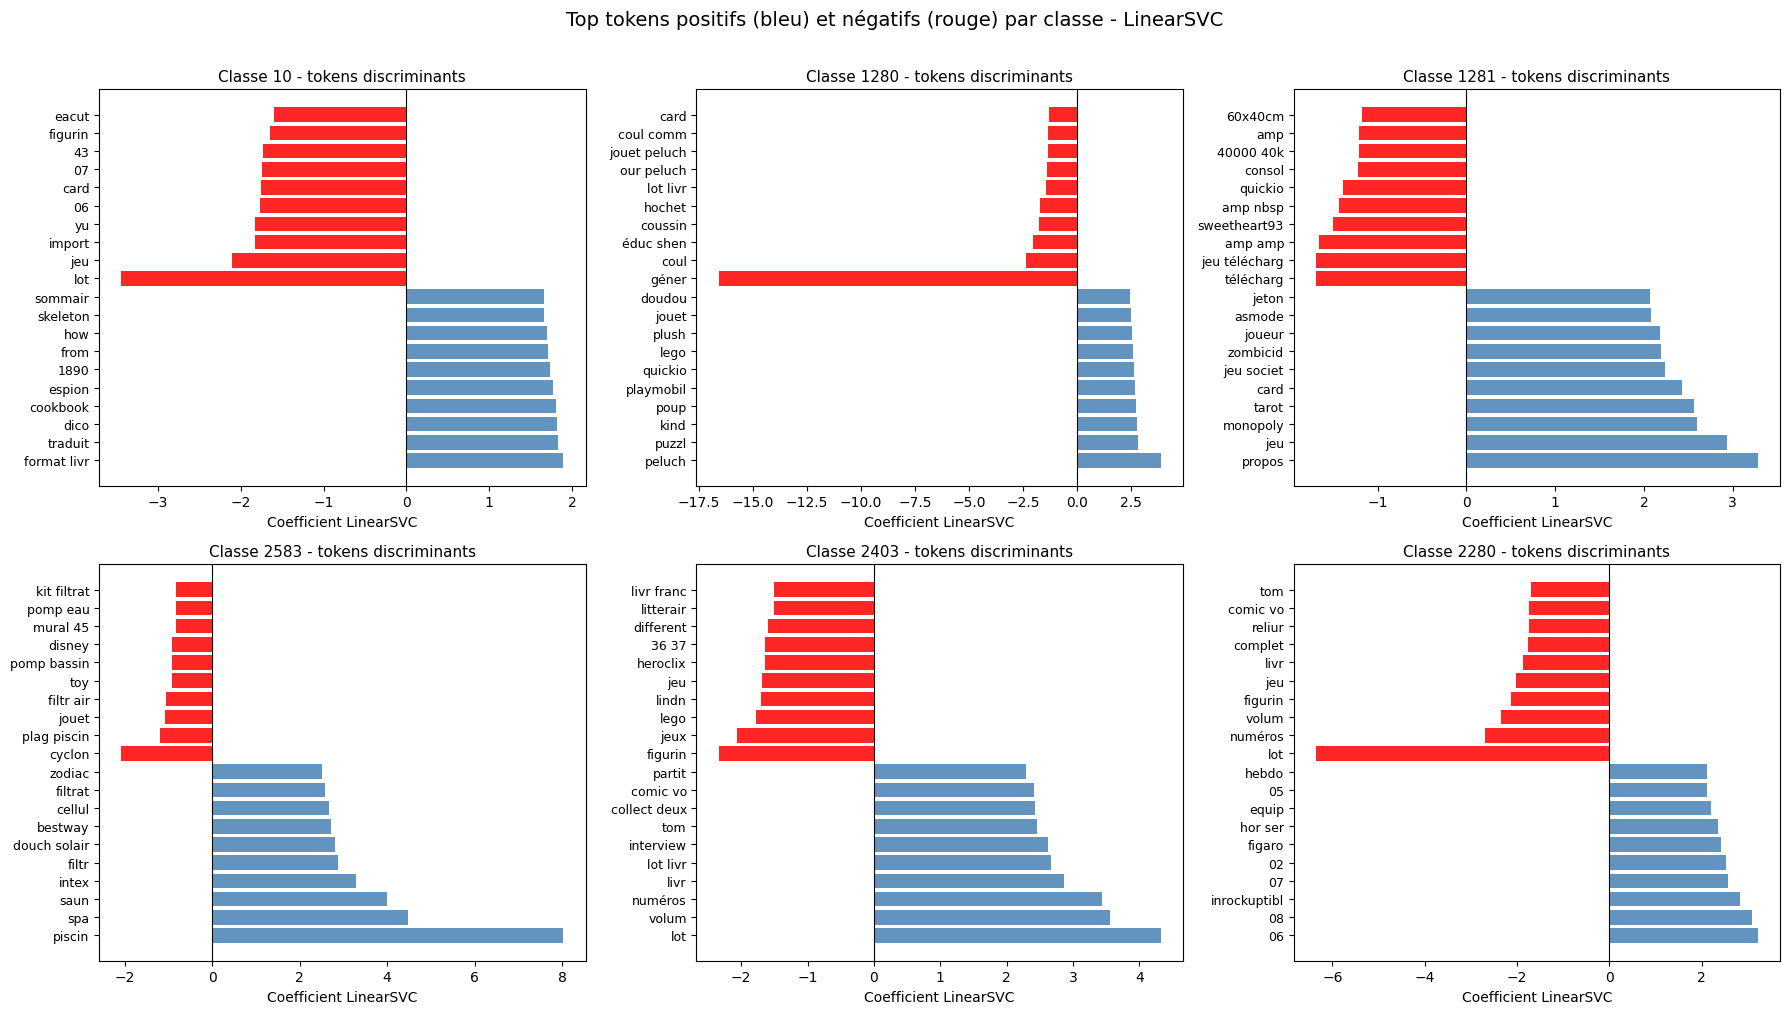

Figure 16 sauvegardée.


In [19]:
# Coefficients du LinearSVC — top tokens discriminants 
# LinearSVC expose ses coefficients directement via classifier.coef_
# Shape : (n_classes, n_features) en classification multiclasse OvR

coef = classifier.coef_  # (27, n_tokens)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax_idx, cls in enumerate(classes_to_show):
    cls_position = list(le.classes_).index(cls)
    cls_coef = coef[cls_position]

    # Top 10 positifs et top 10 négatifs
    top_pos_idx = np.argsort(cls_coef)[::-1][:10]
    top_neg_idx = np.argsort(cls_coef)[:10]

    tokens = np.concatenate([feature_names[top_pos_idx], feature_names[top_neg_idx]])
    scores = np.concatenate([cls_coef[top_pos_idx], cls_coef[top_neg_idx]])
    colors = ["steelblue" if s > 0 else "red" for s in scores]

    ax = axes[ax_idx]
    ax.barh(range(len(tokens)), scores, color=colors, alpha=0.85)
    ax.set_yticks(range(len(tokens)))
    ax.set_yticklabels(tokens, fontsize=9)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(f"Classe {cls} - tokens discriminants", fontsize=11)
    ax.set_xlabel("Coefficient LinearSVC")

plt.suptitle("Top tokens positifs (bleu) et négatifs (rouge) par classe - LinearSVC",
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "16_shap_tokens_par_classe.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 16 sauvegardée.")

Les graphiques confirment la spécialisation de certains tokens :
- Pour la **classe 1280**, `peluch`, `puzzl`, `poup`, `playmobil` et `lego` figurent parmi les coefficients positifs les plus élevés.
- Pour la **classe 2583**, `piscin` atteint environ +8,03, nettement au-dessus des autres coefficients positifs affichés pour cette classe.
- Pour la **classe 10**, `lot` est le coefficient négatif de plus grande amplitude parmi les tokens affichés, ce qui concorde avec la proximité observée avec la classe 2403.

Les coefficients décrivent les associations apprises par le LinearSVC. Ils ne suffisent pas, à eux seuls, à établir une relation causale.


### 4.4 Contributions locales pour un exemple individuel

On prend un produit de classe 10 prédit comme 2280. Pour chaque token présent, on multiplie sa valeur TF-IDF par le coefficient LinearSVC associé à la classe 2280. Le résultat est sa contribution additive locale au score de décision de cette classe, hors intercept. Il ne s'agit pas d'une valeur SHAP produite par l'explainer. On affiche les 15 tokens ayant la contribution absolue la plus élevée.

=== Exemple mal classé : réel=10, prédit=2280 ===
Désignation : La Responsabilite Des Gens De Justice / Revue Justice No 5 1997
Description : nan



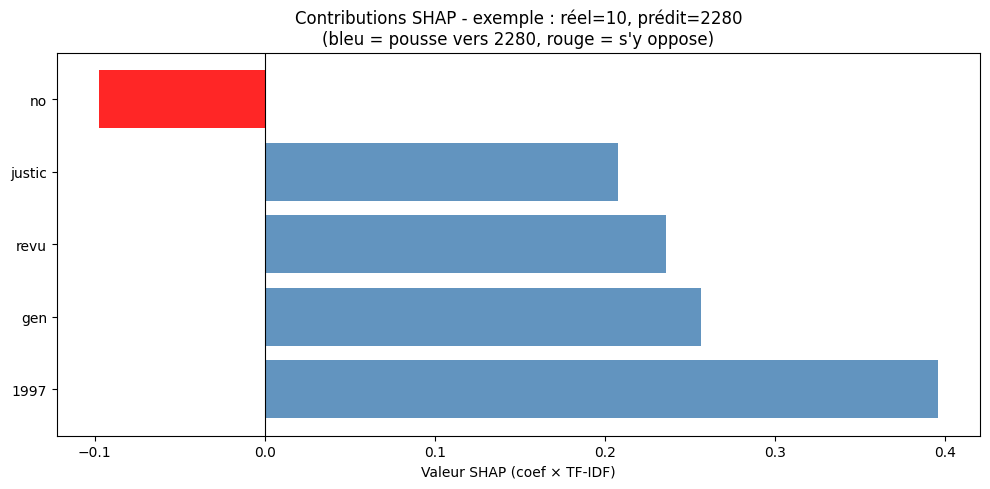

Figure 17 sauvegardée.


In [20]:
# Contributions locales sur un exemple individuel mal classé
# On prend un exemple de la classe 10 prédit comme 2280 (confusion la plus fréquente)

errors_10_2280 = df_val_results[
    (df_val_results["y_true"] == 10) & (df_val_results["y_pred"] == 2280)]

if len(errors_10_2280) > 0:
    example = errors_10_2280.iloc[0]
    print("=== Exemple mal classé : réel=10, prédit=2280 ===")
    print(f"Désignation : {example['designation']}")
    print(f"Description : {str(example.get('description', ''))[:200]}")
    print()

    # Vecteur TF-IDF de cet exemple
    x_example = vectorizer.transform([example["text_combined"]])

    # Extraction des tokens non nuls
    nonzero_idx = x_example.nonzero()[1]
    tokens_ex   = feature_names[nonzero_idx]

    # Classe prédite (2280) = position dans le LabelEncoder
    pred_cls_idx = list(le.classes_).index(2280)

    # Contribution additive locale de chaque token au score de décision :
    # coefficient LinearSVC × valeur TF-IDF du token, hors intercept
    # Ce calcul ne fait pas appel à l'explainer SHAP
    cls_coef_2280 = classifier.coef_[pred_cls_idx]
    sv_ex = cls_coef_2280[nonzero_idx] * np.array(x_example.todense()).flatten()[nonzero_idx]

    # Tri par valeur absolue — top 15 tokens les plus influents
    order   = np.argsort(np.abs(sv_ex))[::-1][:15]
    t_names = tokens_ex[order]
    t_vals  = sv_ex[order]
    colors  = ["steelblue" if v > 0 else "red" for v in t_vals]

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(range(len(t_names)), t_vals, color=colors, alpha=0.85)
    ax.set_yticks(range(len(t_names)))
    ax.set_yticklabels(t_names, fontsize=10)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(
        "Contributions locales - exemple : réel=10, prédit=2280\n"
        "(bleu = pousse vers 2280, rouge = s'y oppose)",
        fontsize=12)
    
    ax.set_xlabel("Contribution locale (coefficient × TF-IDF)")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "17_shap_exemple_individuel.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Figure 17 sauvegardée.")
else:
    print("Aucune erreur 10→2280 trouvée dans cet échantillon de validation.")

L'exemple analysé est *La Responsabilite Des Gens De Justice / Revue Justice No 5 1997*, un produit de classe 10 prédit comme 2280. Les contributions positives vers 2280 proviennent principalement de `1997`, `gen`, `revu` et `justic`. Le token `no` s'oppose légèrement à cette prédiction. La présence explicite du mot `revue` et d'une année fournit au modèle un signal caractéristique de la presse, ce qui explique cette confusion.


## 5 - Analyse des classes difficiles

Focus sur les classes 10 (F1 = 0,526) et 1281 (F1 = 0,598), les deux plus difficiles du modèle baseline. Les classes 1180 et 1280 restent également sous le seuil de 0,70. On compare les prédictions des différents modèles sur les deux classes les plus faibles et on examine visuellement certains exemples mal classés.


### 5.1 Prédictions des 3 modèles sur la validation

On régénère les prédictions du MLP SBERT et du MLP Fusion sur l'ensemble de validation, en utilisant les caches d'embeddings déjà chargés. Cette étape évite tout recalcul d'embeddings et garantit des temps d'inférence rapides. On vérifie ensuite les F1 globaux pour s'assurer de la cohérence avec les résultats du notebook 02.

In [21]:
# Prédictions de tous les modèles sur le set de validation

# MLP SBERT
val_emb_dataset = EmbeddingDataset(emb_val, y_val_enc)
val_emb_loader  = DataLoader(val_emb_dataset, batch_size=256, shuffle=False, num_workers=0)

preds_sbert, labels_list = [], []
mlp_sbert.eval()
with torch.no_grad():
    for Xb, yb in val_emb_loader:
        Xb = Xb.to(DEVICE)
        preds_sbert.extend(mlp_sbert(Xb).argmax(dim=1).cpu().numpy())
        labels_list.extend(yb.numpy())
y_pred_sbert_enc = np.array(preds_sbert)
y_pred_sbert_val = le.inverse_transform(y_pred_sbert_enc)
print(f"MLP SBERT   - F1 val : {f1_score(y_val, y_pred_sbert_val, average='weighted'):.4f}")

# MLP Fusion
val_mm_dataset = EmbeddingDataset(mm_val, y_val_enc)
val_mm_loader  = DataLoader(val_mm_dataset, batch_size=256, shuffle=False, num_workers=0)

preds_fusion = []
mlp_fusion.eval()
with torch.no_grad():
    for Xb, yb in val_mm_loader:
        Xb = Xb.to(DEVICE)
        preds_fusion.extend(mlp_fusion(Xb).argmax(dim=1).cpu().numpy())
y_pred_fusion_enc = np.array(preds_fusion)
y_pred_fusion_val = le.inverse_transform(y_pred_fusion_enc)
print(f"MLP Fusion  - F1 val : {f1_score(y_val, y_pred_fusion_val, average='weighted'):.4f}")

# Résumé
print(f"TF-IDF+SVC  - F1 val : {f1_score(y_val, y_pred_svc_val, average='weighted'):.4f}")

MLP SBERT   - F1 val : 0.7542
MLP Fusion  - F1 val : 0.7105
TF-IDF+SVC  - F1 val : 0.8316


Les F1 pondérés sont cohérents avec le notebook 02 :
- **TF-IDF + LinearSVC** : 0,8316, meilleur modèle évalué
- **MLP SBERT** : 0,7542
- **MLP Fusion** : 0,7105

La fusion retrouve exactement le meilleur score enregistré dans le notebook 02. Les caches SBERT et ResNet restent structurellement compatibles, mais leur cohérence sémantique exacte avec les checkpoints les plus récents n'est pas garantie.


### 5.2 Comparaison F1 par classe : 3 modèles

On calcule le rapport de classification pour les 3 modèles et on les joint dans un DataFrame commun, trié par F1 SVC croissant. Cela permet d'identifier les classes où le SVC domine, celles où SBERT ou la Fusion apportent une valeur ajoutée.

In [22]:
# Comparaison F1 par classe : TF-IDF vs MLP SBERT vs Fusion 
report_sbert  = classification_report(y_val, y_pred_sbert_val,  output_dict=True, zero_division=0)
report_fusion = classification_report(y_val, y_pred_fusion_val, output_dict=True, zero_division=0)

df_compare = pd.DataFrame([
    {
        "classe":  cls,
        "f1_svc":  report_dict[str(cls)]["f1-score"],
        "f1_sbert": report_sbert.get(str(cls), {}).get("f1-score", 0),
        "f1_fusion": report_fusion.get(str(cls), {}).get("f1-score", 0),
        "support":  report_dict[str(cls)]["support"]
    }
    for cls in classes
]).sort_values("f1_svc")

print("F1 par classe - 3 modèles (trié par F1 SVC croissant) :")
print(df_compare.head(10).to_string(index=False))

F1 par classe - 3 modèles (trié par F1 SVC croissant) :
 classe   f1_svc  f1_sbert  f1_fusion  support
     10 0.525799  0.457286   0.661466    623.0
   1281 0.598179  0.528302   0.409666    414.0
   1180 0.682171  0.512605   0.425532    153.0
   1280 0.691529  0.603258   0.465694    974.0
   2705 0.717808  0.684404   0.872827    552.0
     40 0.723093  0.602941   0.674394    502.0
   2403 0.729958  0.667349   0.717629    955.0
   2280 0.754791  0.736789   0.802266    952.0
   2582 0.778109  0.719352   0.554040    518.0
   1140 0.804788  0.683446   0.690047    534.0


Résultats clés sur les 10 classes les plus difficiles pour le SVC :
- **Classe 10** : la Fusion atteint 0,661, contre 0,526 pour le SVC et 0,457 pour SBERT. Le signal visuel apporte ici une amélioration nette.
- **Classe 1281** : le SVC atteint 0,598, contre 0,528 pour SBERT et 0,410 pour la Fusion. La fusion dégrade les performances de cette classe.
- **Classe 1180** : le SVC atteint 0,682, contre 0,513 pour SBERT et 0,426 pour la Fusion.
- **Classe 1280** : le SVC atteint 0,692, contre 0,603 pour SBERT et 0,466 pour la Fusion.
- **Classe 2705** : la Fusion atteint 0,873, contre 0,718 pour le SVC et 0,684 pour SBERT. Le signal visuel est particulièrement utile pour cette classe.


### 5.3 Visualisation comparative F1 par classe

Le graphique compare les F1 des trois modèles pour les 27 classes, triées par F1 SVC croissant. Les lignes de référence indiquent le seuil F1 de 0,70 et le F1 pondéré global du meilleur modèle, soit 0,8316.


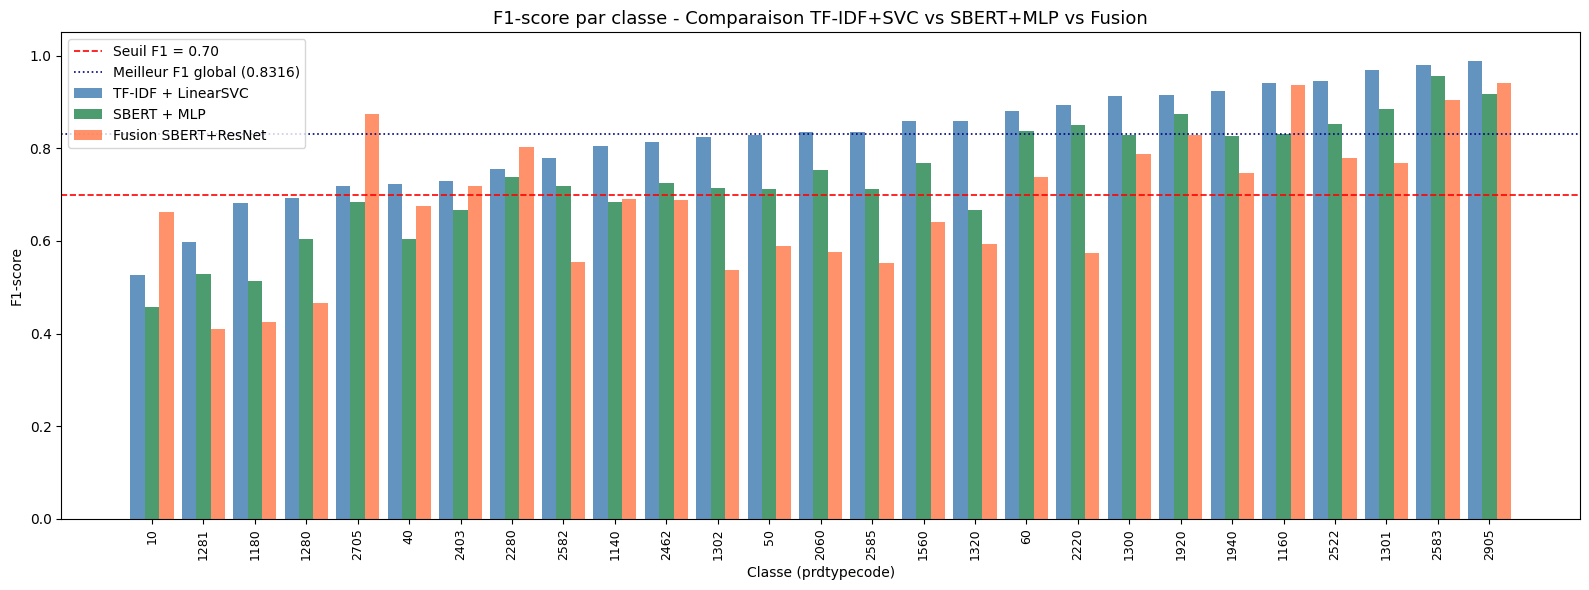

Figure 18 sauvegardée.


In [23]:
# Visualisation : F1 par classe pour les 3 modèles
fig, ax = plt.subplots(figsize=(16, 6))

x    = np.arange(len(df_compare))
w    = 0.28
cls_labels = df_compare["classe"].astype(str).tolist()

ax.bar(x - w,  df_compare["f1_svc"],    width=w, label="TF-IDF + LinearSVC", color="steelblue",  alpha=0.85)
ax.bar(x,      df_compare["f1_sbert"],  width=w, label="SBERT + MLP",        color="seagreen",   alpha=0.85)
ax.bar(x + w,  df_compare["f1_fusion"], width=w, label="Fusion SBERT+ResNet",color="coral",      alpha=0.85)

ax.axhline(0.70, color="red",    linestyle="--", linewidth=1.2, label="Seuil F1 = 0.70")
ax.axhline(f1_val, color="navy", linestyle=":", linewidth=1.2, label=f"Meilleur F1 global ({f1_val:.4f})")

ax.set_xticks(x)
ax.set_xticklabels(cls_labels, rotation=90, fontsize=9)
ax.set_xlabel("Classe (prdtypecode)")
ax.set_ylabel("F1-score")
ax.set_title("F1-score par classe - Comparaison TF-IDF+SVC vs SBERT+MLP vs Fusion", fontsize=13)
ax.legend(fontsize=10)
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "18_f1_par_classe_comparaison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 18 sauvegardée.")

Le graphique confirme que TF-IDF + LinearSVC domine globalement. Le SBERT seul reste inférieur au SVC pour toutes les classes affichées. La Fusion dépasse nettement le SVC pour les classes 10 et 2705, mais reste en retrait sur la majorité des autres classes. Le vocabulaire TF-IDF avec bigrammes capture donc mieux, dans l'ensemble, les distinctions présentes dans ce jeu de données.


### 5.4 Analyse visuelle des classes difficiles

On affiche les images des produits mal classés pour les classes 10 et 1281. Cette analyse qualitative permet de vérifier si l'image aurait pu aider à corriger l'erreur, ou si la confusion est intrinsèque même visuellement.

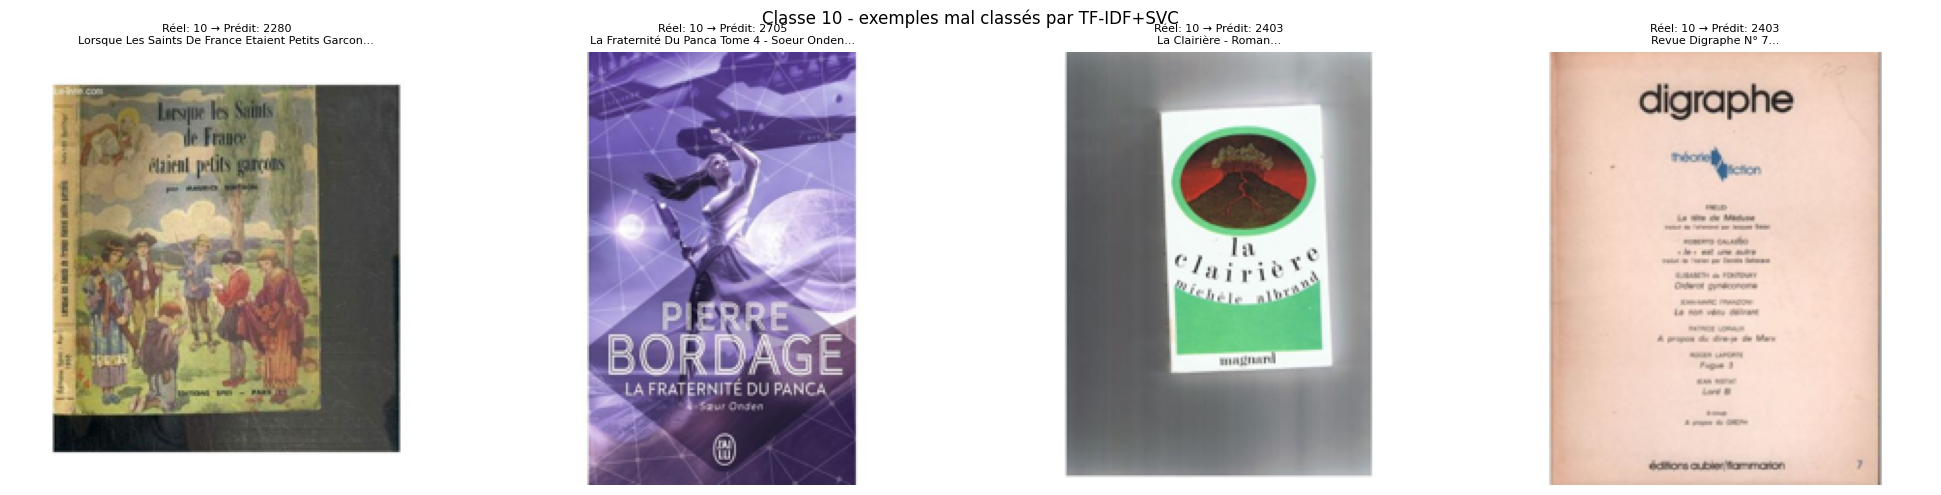

Figure 19_erreurs_classe_10.png sauvegardée.


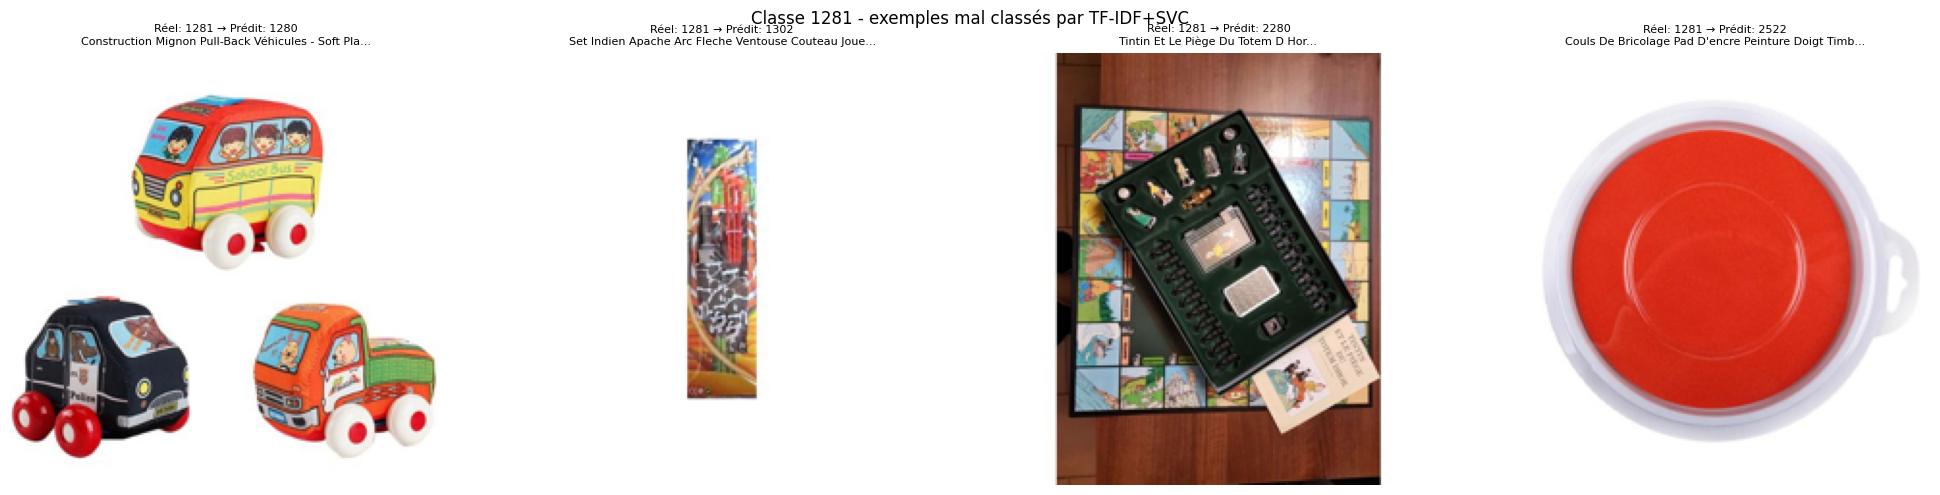

Figure 19_erreurs_classe_1281.png sauvegardée.


In [24]:
# Focus classes difficiles : exemples avec images 
# Affichage d'exemples mal classés de la classe 10 avec leur image produit

difficult_classes = [10, 1281]

for target_cls in difficult_classes:
    # Erreurs du TF-IDF sur cette classe
    mask_errors = (
        (df_val_results["y_true"] == target_cls) &
        (~df_val_results["correct"]))
    
    cls_errors = df_val_results[mask_errors]

    n_show = min(4, len(cls_errors))
    if n_show == 0:
        print(f"Aucune erreur pour la classe {target_cls} dans cet échantillon.")
        continue

    sample = cls_errors.sample(n=n_show, random_state=42)

    fig, axes = plt.subplots(1, n_show, figsize=(5 * n_show, 5))
    if n_show == 1:
        axes = [axes]

    for ax, (_, row) in zip(axes, sample.iterrows()):
        img_path = row["image_path"]
        try:
            img = Image.open(img_path).convert("RGB").resize((224, 224))
            ax.imshow(img)
        except Exception:
            ax.text(0.5, 0.5, "Image\nnon disponible", ha="center", va="center", transform=ax.transAxes)

        title = f"Réel: {row['y_true']} → Prédit: {row['y_pred']}\n{row['designation'][:50]}..."
        ax.set_title(title, fontsize=8)
        ax.axis("off")

    plt.suptitle(f"Classe {target_cls} - exemples mal classés par TF-IDF+SVC", fontsize=12)
    plt.tight_layout()
    fig_name = f"19_erreurs_classe_{target_cls}.png"
    plt.savefig(FIGURES_DIR / fig_name, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Figure {fig_name} sauvegardée.")

**Classe 10 :** les quatre exemples sont des ouvrages ou revues, prédits comme 2280, 2705 ou 2403. Leurs couvertures et leurs titres présentent des indices éditoriaux proches de la presse, des séries ou des ouvrages spécialisés, ce qui rend les confusions compréhensibles.

**Classe 1281 :** les exemples sont prédits comme 1280, 2280 ou 2522. Les véhicules miniatures et l'arc-jouet sont visuellement proches de jouets de classe 1280. Le jeu Tintin conserve une apparence de jeu de société, tandis que le tampon encreur présente un signal visuel très éloigné des autres exemples. L'image n'apporte donc pas un signal uniformément fiable pour cette classe.


## 6 - Comparaison croisée des modèles

Analyse des cas où les modèles sont en accord ou en désaccord :
quand est-ce que la fusion corrige le texte, et inversement ?

### 6.1 Analyse des accords et désaccords entre modèles

On construit un DataFrame croisant les prédictions des 3 modèles sur chaque exemple de validation. On calcule 5 indicateurs clés pour comprendre comment les modèles se complètent ou se contredisent.

In [25]:
# Tableau de synthèse des accords et désaccords 
df_cross = X_val[["text_combined", "designation"]].copy()
df_cross["y_true"]     = y_val.values
df_cross["pred_svc"]   = y_pred_svc_val
df_cross["pred_sbert"] = y_pred_sbert_val
df_cross["pred_fusion"]= y_pred_fusion_val

df_cross["ok_svc"]    = df_cross["y_true"] == df_cross["pred_svc"]
df_cross["ok_sbert"]  = df_cross["y_true"] == df_cross["pred_sbert"]
df_cross["ok_fusion"] = df_cross["y_true"] == df_cross["pred_fusion"]

# Cas d'intérêt
n_all_correct  = (df_cross["ok_svc"] & df_cross["ok_sbert"] & df_cross["ok_fusion"]).sum()
n_svc_only     = (df_cross["ok_svc"] & ~df_cross["ok_sbert"] & ~df_cross["ok_fusion"]).sum()
n_fusion_saves = (~df_cross["ok_svc"] & df_cross["ok_fusion"]).sum()
n_svc_saves    = (df_cross["ok_svc"] & ~df_cross["ok_fusion"]).sum()
n_all_wrong    = (~df_cross["ok_svc"] & ~df_cross["ok_sbert"] & ~df_cross["ok_fusion"]).sum()

print(f"Tous corrects (3 modèles d'accord)   : {n_all_correct:5d} / {len(df_cross)}")
print(f"SVC correct seul (SBERT+Fusion faux) : {n_svc_only:5d}")
print(f"Fusion corrige SVC (SVC faux → ok)   : {n_fusion_saves:5d}")
print(f"SVC corrige Fusion (Fusion faux → ok): {n_svc_saves:5d}")
print(f"Tous faux                             : {n_all_wrong:5d}")

Tous corrects (3 modèles d'accord)   :  9810 / 16984
SVC correct seul (SBERT+Fusion faux) :   935
Fusion corrige SVC (SVC faux → ok)   :  1157
SVC corrige Fusion (Fusion faux → ok):  3203
Tous faux                             :  1333


Sur 16 984 exemples de validation :
- **9 810 (57,8 %)** sont correctement classés par les trois modèles.
- **3 203** cas sont correctement classés par le SVC mais pas par la Fusion.
- **1 157** cas sont corrigés par la Fusion alors que le SVC se trompe.
- **935** cas sont correctement classés uniquement par le SVC.
- **1 333 (7,8 %)** sont mal classés par les trois modèles.

Le SVC corrige donc davantage d'erreurs de la Fusion que la Fusion n'en corrige pour le SVC. Les 1 333 erreurs communes constituent un ensemble prioritaire pour une analyse complémentaire.


### 6.2 Visualisation du chevauchement des erreurs

On visualise le nombre d'exemples mal classés pour chaque configuration d'accord/désaccord entre les 3 modèles, sous forme de barres. Cela permet de quantifier la complémentarité des modèles et d'identifier les gains théoriques d'un système d'ensemble.

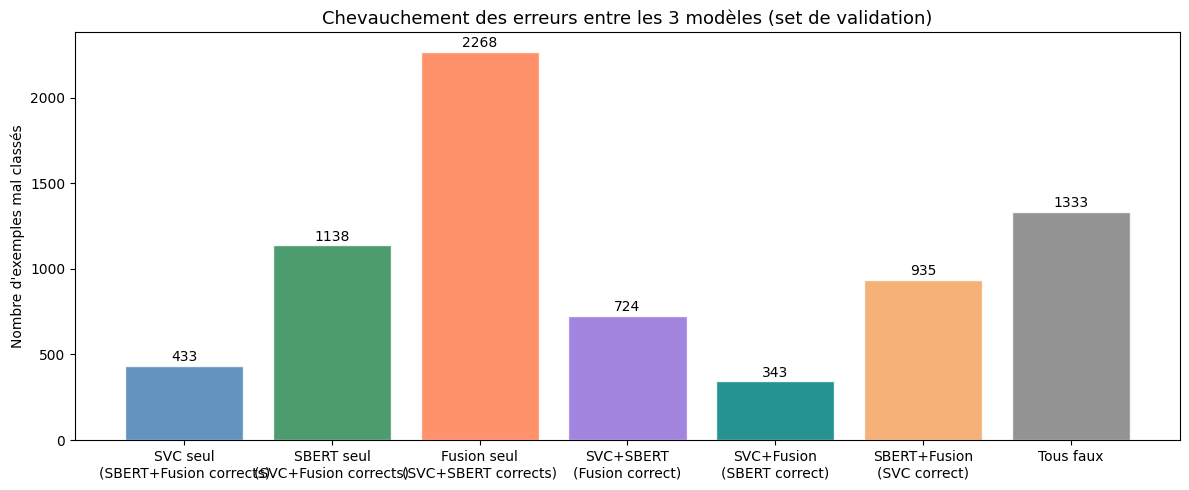

Figure 20 sauvegardée.


In [26]:
# Visualisation : diagramme de Venn des erreurs
# Ensembles d'indices mal classés par chaque modèle
err_svc    = set(np.where(~df_cross["ok_svc"].values)[0])
err_sbert  = set(np.where(~df_cross["ok_sbert"].values)[0])
err_fusion = set(np.where(~df_cross["ok_fusion"].values)[0])

# Barres de chevauchement
categories = [
    "SVC seul\n(SBERT+Fusion corrects)",
    "SBERT seul\n(SVC+Fusion corrects)",
    "Fusion seul\n(SVC+SBERT corrects)",
    "SVC+SBERT\n(Fusion correct)",
    "SVC+Fusion\n(SBERT correct)",
    "SBERT+Fusion\n(SVC correct)",
    "Tous faux"]

values = [
    len(err_svc  - err_sbert - err_fusion),
    len(err_sbert - err_svc  - err_fusion),
    len(err_fusion - err_svc - err_sbert),
    len((err_svc & err_sbert) - err_fusion),
    len((err_svc & err_fusion) - err_sbert),
    len((err_sbert & err_fusion) - err_svc),
    len(err_svc & err_sbert & err_fusion)]


fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(categories, values,
              color=["steelblue","seagreen","coral","mediumpurple","teal","sandybrown","grey"],
              alpha=0.85, edgecolor="white")
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, str(val),
            ha="center", va="bottom", fontsize=10)
ax.set_ylabel("Nombre d'exemples mal classés")
ax.set_title("Chevauchement des erreurs entre les 3 modèles (set de validation)", fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "20_chevauchement_erreurs.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 20 sauvegardée.")

La configuration la plus fréquente est **Fusion seule en erreur**, avec 2 268 exemples que le SVC et SBERT classent correctement. Elle confirme que la fusion actuelle dégrade de nombreux cas bien traités par les modèles textuels. On observe aussi 1 138 erreurs propres à SBERT et 433 erreurs propres au SVC. Les trois modèles échouent simultanément sur 1 333 exemples. Les 343 cas où le SVC et la Fusion échouent mais où SBERT réussit montrent que chaque modèle conserve une part de complémentarité. Ces comptages ne suffisent toutefois pas à définir directement une stratégie de vote optimale.


### 6.3 Exemples où la fusion corrige le SVC

On examine qualitativement les 1 157 cas où la Fusion prédit correctement alors que le SVC échoue. Ces exemples représentent les situations où l'ajout du signal visuel apporte une valeur mesurable.


In [27]:
# Exemples où la fusion corrige ce que le TF-IDF rate 
fusion_saves = df_cross[~df_cross["ok_svc"] & df_cross["ok_fusion"]]

print(f"Cas où la fusion corrige le TF-IDF : {len(fusion_saves)} exemples\n")
for _, row in fusion_saves.head(5).iterrows():
    print(f"Classe réelle : {row['y_true']} | SVC prédit : {row['pred_svc']} | Fusion prédit : {row['pred_fusion']} (correct)")
    print(f"Désignation   : {row['designation'][:100]}")
    print()

Cas où la fusion corrige le TF-IDF : 1157 exemples

Classe réelle : 10 | SVC prédit : 2705 | Fusion prédit : 10 (correct)
Désignation   : Le Silence Des Anges

Classe réelle : 2462 | SVC prédit : 50 | Fusion prédit : 2462 (correct)
Désignation   : Skylanders Giants + Le Plateau

Classe réelle : 1920 | SVC prédit : 2060 | Fusion prédit : 1920 (correct)
Désignation   : Taie Canapé Voiture Taille Throw Coussin Décoration Pillow Case 24098

Classe réelle : 40 | SVC prédit : 2462 | Fusion prédit : 40 (correct)
Désignation   : Fifa 16 - Xbox 360

Classe réelle : 10 | SVC prédit : 40 | Fusion prédit : 10 (correct)
Désignation   : I Saw Her Standing There



Les exemples affichés illustrent plusieurs apports possibles de l'image :
- **Skylanders Giants + Le Plateau** (2462) est corrigé depuis la classe 50 grâce à l'apparence d'une boîte de jeu vidéo.
- **Fifa 16 - Xbox 360** (40) est corrigé depuis la classe 2462, la jaquette fournissant un indice visuel utile.
- **Taie Canapé Voiture** (1920) est corrigée depuis la classe 2060, probablement grâce à la nature visuelle du produit.
- Deux ouvrages de classe 10 sont également corrigés malgré des prédictions textuelles vers 2705 et 40.

Ces exemples confirment que l'image peut compléter une désignation ambiguë, même si la fusion reste globalement moins performante que le SVC.


### 6.4 Tableau récapitulatif final

On consolide les résultats de tous les modèles dans un tableau comparatif unique, ordonné par weighted F1 décroissant, et on le sauvegarde pour référence.

In [28]:
# Tableau récapitulatif final 
final_results = pd.DataFrame([
    {"Modèle": "Benchmark Rakuten — CNN texte",         "Modalité": "Texte",         "Weighted F1": 0.8113},
    {"Modèle": "Benchmark Rakuten — ResNet50 image",    "Modalité": "Image",         "Weighted F1": 0.5534},
    {"Modèle": "TF-IDF + LinearSVC",                    "Modalité": "Texte",         "Weighted F1": f1_score(y_val, y_pred_svc_val,   average="weighted")},
    {"Modèle": "SBERT + MLP",                           "Modalité": "Texte",         "Weighted F1": f1_score(y_val, y_pred_sbert_val,  average="weighted")},
    {"Modèle": "Fusion SBERT + ResNet50",               "Modalité": "Texte + Image", "Weighted F1": f1_score(y_val, y_pred_fusion_val, average="weighted")},
]).sort_values("Weighted F1", ascending=False)

final_results["Weighted F1"] = final_results["Weighted F1"].round(4)
print("=== Résultats finaux ===")
print(final_results.to_string(index=False))

# Sauvegarde
final_results.to_csv(ARTIFACTS_DIR / "resultats_finaux_03.csv", index=False)
print("\nRésultats sauvegardés dans models/artifacts/resultats_finaux_03.csv")

=== Résultats finaux ===
                            Modèle      Modalité  Weighted F1
                TF-IDF + LinearSVC         Texte       0.8316
     Benchmark Rakuten — CNN texte         Texte       0.8113
                       SBERT + MLP         Texte       0.7542
           Fusion SBERT + ResNet50 Texte + Image       0.7105
Benchmark Rakuten — ResNet50 image         Image       0.5534

Résultats sauvegardés dans models/artifacts/resultats_finaux_03.csv


**Résultats finaux :**

| Modèle | Modalité | Weighted F1 |
|---|---|---|
| TF-IDF + LinearSVC | Texte | **0,8316** |
| Benchmark Rakuten CNN | Texte | 0,8113 |
| SBERT + MLP | Texte | 0,7542 |
| Fusion SBERT + ResNet50 | Texte + Image | 0,7105 |
| Benchmark ResNet50 image | Image | 0,5534 |

Le modèle TF-IDF + LinearSVC dépasse le benchmark Rakuten de 0,0203 et reste le meilleur modèle évalué. La fusion multimodale ne dépasse pas les approches textuelles dans sa configuration actuelle, malgré des gains localisés pour certaines classes, notamment 10 et 2705. Des pistes d'amélioration restent la normalisation par modalité, une fusion avec pondération ou attention, et le fine-tuning d'un modèle de langue sur les textes du projet.


### Récapitulatif des fichiers produits

On affiche la liste complète des fichiers générés par ce notebook : fichier de soumission, figures d'analyse, et tableau de résultats.

In [29]:
print("="*60)
print("Notebook 03 terminé.")
print("Fichiers produits :")
print("  data/submissions/submission_tfidf_svc.csv")
print("  reports/figures/14_distribution_predictions_test.png")
print("  reports/figures/15_confusion_classes_faibles.png")
print("  reports/figures/16_shap_tokens_par_classe.png")
print("  reports/figures/17_shap_exemple_individuel.png")
print("  reports/figures/18_f1_par_classe_comparaison.png")
print("  reports/figures/19_erreurs_classe_10.png")
print("  reports/figures/19_erreurs_classe_1281.png")
print("  reports/figures/20_chevauchement_erreurs.png")
print("  models/artifacts/resultats_finaux_03.csv")
print("="*60)

Notebook 03 terminé.
Fichiers produits :
  data/submissions/submission_tfidf_svc.csv
  reports/figures/14_distribution_predictions_test.png
  reports/figures/15_confusion_classes_faibles.png
  reports/figures/16_shap_tokens_par_classe.png
  reports/figures/17_shap_exemple_individuel.png
  reports/figures/18_f1_par_classe_comparaison.png
  reports/figures/19_erreurs_classe_10.png
  reports/figures/19_erreurs_classe_1281.png
  reports/figures/20_chevauchement_erreurs.png
  models/artifacts/resultats_finaux_03.csv


Le notebook 03 est complet. Les 9 figures et le fichier de soumission sont disponibles dans les répertoires `reports/figures/` et `data/submissions/`. Le fichier `resultats_finaux_03.csv` centralise les métriques pour le rapport final.